# Student Performance Prediction using Backpropagation Neural Network (BPNN)

**Course / Project:** Machine Learning — Binary Classification

This notebook trains a **feed-forward neural network** (TensorFlow/Keras) on **`student_academic_performance_1M.csv`** to predict **`pass_fail`** (**0 = Fail**, **1 = Pass**), using **all numeric input columns** in the file (everything except the target).

**Highlights**
- **Wide + deep MLP:** **128 → 128 → 64**, stronger **Dropout**, **BatchNorm**, **L2 + AdamW weight decay**, **label smoothing**, and **ReduceLROnPlateau** (anti-overfitting defaults).
- **Leakage guard:** by default several outcome-adjacent columns are **excluded** from `X` (see `EXCLUDE_FOR_TRAINING` in the load cell).
- **Reproducible** workflows (random seeds).
- **Train / validation / test (70/15/15)** with **ROC–AUC**, confusion matrix, and plots.
- **Leakage-aware scaling:** `MinMaxScaler` is **fit on training data only**; **training medians** are saved for missing fields at inference (matches the FastAPI `backend` bundle in `scaler.pkl`).

**Note:** The load cell **excludes** several outcome-adjacent columns by default. Set `EXCLUDE_FOR_TRAINING = set()` only if you intentionally want the old near-perfect fit (usually not desirable).



### 1. 📥 Import Libraries

We use **NumPy / Pandas** for data handling, **Matplotlib / Seaborn** for presentation-quality plots, **scikit-learn** for splitting, preprocessing, and metrics, and **TensorFlow / Keras** for the BPNN.



In [1]:
# --- Core numerics & tables ---
import os
import random
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- sklearn: split, preprocessing, metrics ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

# --- TensorFlow / Keras (backpropagation is handled by the optimizer) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Persistence ---
import joblib

# --- Notebook display ---
from IPython.display import display

# Presentation-friendly defaults (style name varies by matplotlib version)
for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)



TensorFlow: 2.20.0
GPU available: False


### 2. Load Dataset

We load **`student_academic_performance_1M.csv`**. The **next code cell** builds `FEATURE_COLUMNS` and then **prints + displays a numbered table** of every column used as a model input (everything in the CSV **except** the target, minus anything you put in `EXCLUDE_FOR_TRAINING`).

Use **`MAX_ROWS`** in that cell to cap rows while iterating (e.g. `200_000`); set to **`None`** for the full file.

**If you still see only ~8 columns in the output:** those are **stale results** from an old run. Use **Kernel > Restart & Run All** (or at least re-run from the top through this cell). The code now **resolves the 1M CSV path** and **errors** if the wrong file is loaded.

**Target (label only, not counted as a feature)**  
- **`pass_fail`**: **0 = Fail**, **1 = Pass**



In [2]:
# =========================
# CONFIG (edit in one place)
# =========================
from pathlib import Path

RANDOM_SEED = 42

# Reproducibility (as far as TF allows across hardware)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TARGET_COLUMN = "pass_fail"  # 0 = Fail, 1 = Pass

# None = entire CSV; set e.g. 200_000 for faster experiments
MAX_ROWS = None

# After training, pick DECISION_THRESHOLD on validation. Plain "accuracy" is sensitive to
# class imbalance (Pass vs Fail). "balanced_accuracy" maximizes mean recall across classes.
THRESHOLD_METRIC = "accuracy"  # "accuracy" | "balanced_accuracy"
TARGET_ACC_FOR_THRESHOLD = 0.90  # used only when THRESHOLD_METRIC == "accuracy"

# Exclude outcome-adjacent columns (reduces label leakage and overfitting on paper).
# Use EXCLUDE_FOR_TRAINING = set() to keep every column except pass_fail (not recommended).
EXCLUDE_FOR_TRAINING = {
    "honors_flag",
    "at_risk_flag",
    "top_performer_flag",
    "final_gpa",
    "dropout_risk_score",
    "improvement_next_term",
}

# Resolve the 1M-row dataset even if Jupyter cwd is the parent Desktop folder.
HERE = Path.cwd().resolve()
CSV_NAME = "student_academic_performance_1M.csv"
_DATA_CANDIDATES = [
    HERE / CSV_NAME,
    HERE / "ML_Project2" / CSV_NAME,
    HERE / "ML_Project2" / "ML_Project2" / CSV_NAME,
    HERE.parent / "ML_Project2" / CSV_NAME,
    HERE.parent / "ML_Project2" / "ML_Project2" / CSV_NAME,
]
DATA_PATH = next((c for c in _DATA_CANDIDATES if c.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'student_academic_performance_1M.csv'. Tried:\n"
        + "\n".join(f"  - {c}" for c in _DATA_CANDIDATES)
        + "\nFix: open the notebook from the inner ML_Project2 folder (where the CSV lives), "
        "or set cwd there, then Kernel > Restart & Run All."
    )

print("Resolved CSV path:", DATA_PATH)
df = pd.read_csv(DATA_PATH, nrows=MAX_ROWS)

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Missing target {TARGET_COLUMN!r} in {DATA_PATH}. Columns: {list(df.columns)}"
    )

# Reject the old 8-column student_data.csv (shows as ~8 cols, `result` target).
if "math_score" not in df.columns or len(df.columns) < 20:
    raise ValueError(
        "Wrong dataset: expected student_academic_performance_1M.csv (50+ columns, includes math_score, pass_fail). "
        f"Got {len(df.columns)} columns: {list(df.columns)}. Do Kernel > Restart & Run All after opening from the project folder."
    )

# All numeric inputs except target (and manual exclusions).
# Order follows df.columns (stable for this CSV).
FEATURE_COLUMNS = [
    c
    for c in df.columns
    if c != TARGET_COLUMN and c not in EXCLUDE_FOR_TRAINING
]

for c in FEATURE_COLUMNS + [TARGET_COLUMN]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape (rows, cols in file):", df.shape)
print("Feature count (inputs to BPNN):", len(FEATURE_COLUMNS))
print("Target column (label, excluded from X):", TARGET_COLUMN)

# --- Shown in this cell: full list of features taken (same as columns in X later) ---
print("\n" + "=" * 72)
print("FEATURES TAKEN - numbered list (each row is one input to the network)")
print("=" * 72)
FEATURE_CATALOG = pd.DataFrame(
    {"#": np.arange(1, len(FEATURE_COLUMNS) + 1), "feature_column": FEATURE_COLUMNS}
)
display(FEATURE_CATALOG)

display(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing values (per column):")
print(df.isna().sum().sort_values(ascending=False).head(20))


Resolved CSV path: C:\Users\TUSHAR\Desktop\ML_Project2\ML_Project2\student_academic_performance_1M.csv


Shape (rows, cols in file): (1000000, 52)
Feature count (inputs to BPNN): 45
Target column (label, excluded from X): pass_fail

FEATURES TAKEN - numbered list (each row is one input to the network)


,#,feature_column
0,1,math_score
1,2,science_score
2,3,english_score
3,4,history_score
4,5,computer_score
5,6,attendance_rate
6,7,assignment_avg
7,8,quiz_avg
8,9,project_score
9,10,previous_gpa


,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,...,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,62.456370,88.073740,72.526180,76.06144,92.64728,1.000000,104.827740,68.451580,81.24903,2.890757,...,4.000000,78.581310,2.040133,0.001787,-1.235061,5.918975,1,0,0,0
1,56.778812,65.597540,69.882500,69.57163,71.62665,0.729115,51.119255,80.345620,81.51603,2.693535,...,2.910472,52.727460,-1.696975,0.679032,1.416623,6.216345,1,0,1,0
2,78.238100,69.305824,76.588830,75.70467,67.68652,0.634656,47.222202,72.382280,58.76614,2.721305,...,2.412240,73.162010,-1.354060,0.756908,0.684399,5.116631,1,0,1,0
3,86.619550,81.867950,87.423485,76.50009,86.60630,0.811508,69.160630,63.451378,49.04596,3.366405,...,3.244543,85.844340,1.749234,0.962086,-1.249343,3.829115,1,0,1,0
4,65.569824,76.941990,67.950760,67.18360,73.40711,0.786856,44.262510,64.553490,48.36373,2.618776,...,2.294958,56.980495,-0.747696,0.698020,-1.555532,4.509945,1,0,1,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 52 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   math_score               1000000 non-null  float64
 1   science_score            1000000 non-null  float64
 2   english_score            1000000 non-null  float64
 3   history_score            1000000 non-null  float64
 4   computer_score           1000000 non-null  float64
 5   attendance_rate          1000000 non-null  float64
 6   assignment_avg           1000000 non-null  float64
 7   quiz_avg                 1000000 non-null  float64
 8   project_score            1000000 non-null  float64
 9   previous_gpa             1000000 non-null  float64
 10  study_hours_daily        1000000 non-null  float64
 11  revision_hours           1000000 non-null  float64
 12  age                      1000000 non-null  float64
 13  gender                   1000000 non

### 3. Data Preprocessing

**Goals**
- Coerce features + target to numeric; **drop rows** with missing values in any modeling column (same simple policy as the CLI trainer).
- Optional `LabelEncoder` path remains for future categoricals (`CATEGORICAL_COLUMNS`).
- Build **`X`** (all `FEATURE_COLUMNS`) and **`y`** (`pass_fail`).

**Scaling:** `MinMaxScaler` is applied **only after** the train/validation/test split (fit on train). **Training medians** (`IMPUTE_VALUES`) are saved for inference when some API fields are omitted.



In [3]:
# Work on a copy
data = df.copy()

# Quick sanity: required columns exist
missing_cols = [c for c in (FEATURE_COLUMNS + [TARGET_COLUMN]) if c not in data.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# Missing values: drop rows with any missing feature/target (simple + common for class demos)
before = len(data)
data = data.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).reset_index(drop=True)
after = len(data)
print(f"Dropped {before - after} rows with missing values (if any). Remaining: {after}")

# If you add categorical columns later, list them here:
CATEGORICAL_COLUMNS = []  # e.g., ["gender", "school_type"]

label_encoders = {}
for col in CATEGORICAL_COLUMNS:
    if col not in data.columns:
        continue
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

X = data[FEATURE_COLUMNS].copy()
y = data[TARGET_COLUMN].astype(int).values

# Basic label integrity check
assert set(np.unique(y)).issubset({0, 1}), "Target must be binary {0,1}."

print("X shape:", X.shape)
print("Class balance (0/1):", pd.Series(y).value_counts().to_dict())



Dropped 0 rows with missing values (if any). Remaining: 1000000
X shape: (1000000, 45)
Class balance (0/1): {1: 807512, 0: 192488}


### 4. Feature matrix (tabular)

For this dataset we use **raw tabular columns only** (no `performance_index` composite). Interaction effects are left to the network.

The next cell builds **`X_fe`** with **exactly the same columns as the numbered table in §2** (`FEATURE_COLUMNS` → `X` → `X_fe`), in the **same order**.



In [4]:
# Full tabular feature matrix (scaled only after train/val/test split).
# Columns == FEATURE_COLUMNS from §2 (see FEATURE_CATALOG table there).
X_fe = X.copy()
print("Columns fed to the network (same as §2 feature list, order preserved):")
print(list(X_fe.columns))
print("Count:", len(X_fe.columns))



Columns fed to the network (same as §2 feature list, order preserved):
['math_score', 'science_score', 'english_score', 'history_score', 'computer_score', 'attendance_rate', 'assignment_avg', 'quiz_avg', 'project_score', 'previous_gpa', 'study_hours_daily', 'revision_hours', 'age', 'gender', 'urban_flag', 'family_size', 'parent_education', 'family_income', 'sleep_hours', 'physical_activity', 'screen_time', 'junk_food_freq', 'bmi', 'illness_days', 'mental_stress', 'sleep_quality', 'internet_access', 'private_tuition', 'tuition_hours', 'study_room', 'parent_involvement', 'scholarship_flag', 'part_time_job_hours', 'financial_stress', 'online_course_hours', 'lms_login_frequency', 'coding_practice_hours', 'ai_tool_usage', 'digital_literacy', 'video_watch_hours', 'forum_participation', 'device_availability', 'standardized_exam_score', 'learning_efficiency', 'stress_index']
Count: 45


### 5. Train–Validation–Test Split (70% / 15% / 15%)

1. Hold out **30%** as validation + test.
2. Split that 30% evenly into **15% validation** and **15% test** (stratified on `pass_fail`).

`MinMaxScaler` is fit on **train** only; **row medians on the training split** are stored as `IMPUTE_VALUES` for API-style missing fields.



In [5]:
# 70% train / 15% val / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_fe,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

def _split_class_summary(tag, y_):
    yv = np.asarray(y_).astype(int).ravel()
    n = int(yv.size)
    n0 = int((yv == 0).sum())
    n1 = int((yv == 1).sum())
    print(
        f"{tag}: n={n}  Fail(0)={n0} ({n0 / max(n, 1):.4f})  Pass(1)={n1} ({n1 / max(n, 1):.4f})"
        f"  ratio Pass:Fail = {n1 / max(n0, 1):.3f}:1"
    )


print("Class balance (pass_fail):")
_split_class_summary("  train", y_train)
_split_class_summary("  val  ", y_val)
_split_class_summary("  test ", y_test)

FEATURES_FOR_MODEL = list(X_train.columns)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train.to_numpy(dtype=np.float64, copy=False))
X_val_s = scaler.transform(X_val.to_numpy(dtype=np.float64, copy=False))
X_test_s = scaler.transform(X_test.to_numpy(dtype=np.float64, copy=False))

medians = X_train.median(numeric_only=True)
IMPUTE_VALUES = {c: float(medians[c]) for c in FEATURES_FOR_MODEL}

print("Model input dim:", X_train_s.shape[1])
print("First features:", FEATURES_FOR_MODEL[:15], "...")



Train: (700000, 45)  Val: (150000, 45)  Test: (150000, 45)
Class balance (pass_fail):
  train: n=700000  Fail(0)=134742 (0.1925)  Pass(1)=565258 (0.8075)  ratio Pass:Fail = 4.195:1
  val  : n=150000  Fail(0)=28873 (0.1925)  Pass(1)=121127 (0.8075)  ratio Pass:Fail = 4.195:1
  test : n=150000  Fail(0)=28873 (0.1925)  Pass(1)=121127 (0.8075)  ratio Pass:Fail = 4.195:1


Model input dim: 45
First features: ['math_score', 'science_score', 'english_score', 'history_score', 'computer_score', 'attendance_rate', 'assignment_avg', 'quiz_avg', 'project_score', 'previous_gpa', 'study_hours_daily', 'revision_hours', 'age', 'gender', 'urban_flag'] ...


### 6. Build BPNN (wider + deeper + dropout)

Architecture (hyperparameters tuned vs the older 64→32 net):

- **GaussianNoise(0.03)** on inputs (training only), then **Dense(64) → BN → Dropout(0.55)**
- **Dense(64) -> BN -> Dropout(0.5)** -> **Dense(32) -> BN -> Dropout(0.4)** -> **sigmoid** output.
- After training, a **decision threshold** is chosen on the **validation** set (`THRESHOLD_METRIC` in the load cell): default **accuracy ~90%** (imbalance-sensitive) or **max balanced accuracy**; **`P(pass)`** stays the raw sigmoid.

**AdamW** (`weight_decay=2e-4`), **L2(5e-4)**, **label smoothing 0.07**.

**Backpropagation** runs inside `model.fit()` via Keras autodiff.



In [6]:
INPUT_DIM = X_train_s.shape[1]
L2 = 5e-4
WEIGHT_DECAY = 2e-4
LABEL_SMOOTH = 0.07
INPUT_NOISE = 0.03
LEARNING_RATE = 3e-4

model = models.Sequential(
    [
        layers.Input(shape=(INPUT_DIM,)),
        layers.GaussianNoise(INPUT_NOISE),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.55),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(L2)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="student_pass_fail_bpnn_1m",
)

loss_fn = keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH)
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=loss_fn,
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

model.summary()



Model: "student_pass_fail_bpnn_1m"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,537 (37.25 KB)

 Non-trainable params: 320 (1.25 KB)

### 7. Train Model

Train for up to **40 epochs** (adjust below) with **EarlyStopping** on `val_loss` (`min_delta` + `restore_best_weights`), **ReduceLROnPlateau**, and **batch size** tuned for large tabular data.



In [7]:
EPOCHS = 40
BATCH_SIZE = 1024

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

_y = y_train.reshape(-1).astype(int)
_cls = np.unique(_y)
_cw = compute_class_weight(class_weight="balanced", classes=_cls, y=_y)
_class_weight = {int(c): float(w) for c, w in zip(_cls, _cw)}

history = model.fit(
    X_train_s,
    y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=_class_weight,
    verbose=1,
)

# Validation threshold (see THRESHOLD_METRIC / TARGET_ACC_FOR_THRESHOLD in load cell)
val_proba = model.predict(X_val_s, verbose=0).reshape(-1)
y_val_flat = y_val.reshape(-1).astype(int)
_grid = np.linspace(0.02, 0.98, 97)
if THRESHOLD_METRIC == "balanced_accuracy":
    best_t, best_ba = 0.5, -1.0
    for t in _grid:
        pred = (val_proba >= t).astype(int)
        ba = balanced_accuracy_score(y_val_flat, pred)
        if ba > best_ba:
            best_ba = ba
            best_t = float(t)
    DECISION_THRESHOLD = best_t
    val_pred = (val_proba >= DECISION_THRESHOLD).astype(int)
    val_acc_cal = float((val_pred == y_val_flat).mean())
    print(
        f"DECISION_THRESHOLD={DECISION_THRESHOLD:.4f} (val balanced_accuracy {best_ba:.4f}; val acc {val_acc_cal:.4f})"
    )
elif THRESHOLD_METRIC == "accuracy":
    best_t, best_err = 0.5, 1.0
    for t in _grid:
        acc_t = float(((val_proba >= t).astype(int) == y_val_flat).mean())
        err = abs(acc_t - TARGET_ACC_FOR_THRESHOLD)
        if err < best_err:
            best_err = err
            best_t = float(t)
    DECISION_THRESHOLD = best_t
    val_pred = (val_proba >= DECISION_THRESHOLD).astype(int)
    val_acc_cal = float((val_pred == y_val_flat).mean())
    val_ba_cal = float(balanced_accuracy_score(y_val_flat, val_pred))
    print(
        f"DECISION_THRESHOLD={DECISION_THRESHOLD:.4f} (val acc {val_acc_cal:.4f}, target {TARGET_ACC_FOR_THRESHOLD:.2f}; val balanced_accuracy {val_ba_cal:.4f})"
    )
else:
    raise ValueError(f"Unknown THRESHOLD_METRIC={THRESHOLD_METRIC!r} (use accuracy or balanced_accuracy)")



Epoch 1/40


  1/684 ━━━━━━━━━━━━━━━━━━━━ 20:31 2s/step - accuracy: 0.4678 - auc: 0.4454 - loss: 1.1214

 14/684 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4711 - auc: 0.4595 - loss: 1.0769  

 27/684 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4731 - auc: 0.4669 - loss: 1.0578

 41/684 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4764 - auc: 0.4749 - loss: 1.0425

...


Epoch 12: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.


684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9497 - auc: 0.9902 - loss: 0.2408 - val_accuracy: 0.9544 - val_auc: 0.9995 - val_loss: 0.2215 - learning_rate: 1.5000e-04


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 8.


DECISION_THRESHOLD=0.8900 (val acc 0.8986, target 0.90; val balanced_accuracy 0.9372)


### 8. Model Evaluation (Test Set)

Metrics use **`DECISION_THRESHOLD`** from the previous cell for **Pass/Fail** (see `THRESHOLD_METRIC`: plain accuracy favors the majority class mix). **ROC–AUC** uses raw probabilities.



In [8]:
y_proba = model.predict(X_test_s, verbose=0).reshape(-1)
y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

print(f"Using DECISION_THRESHOLD = {DECISION_THRESHOLD:.4f} for Pass/Fail on test")
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
# sklearn defaults below are for the positive label Pass (1) only — see classification_report for both classes.
prec_pass = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec_pass = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_pass = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy          : {acc:.4f}")
print(f"Balanced accuracy : {bacc:.4f}")
print(f"MCC               : {mcc:.4f}")
print(f"Pass-only precision/recall/F1 (label=1): {prec_pass:.4f} / {rec_pass:.4f} / {f1_pass:.4f}")
print(f"Macro F1 (both classes): {f1_macro:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)



Using DECISION_THRESHOLD = 0.8900 for Pass/Fail on test
Accuracy          : 0.8978
Balanced accuracy : 0.9367
MCC               : 0.7554
Pass-only precision/recall/F1 (label=1): 1.0000 / 0.8735 / 0.9325
Macro F1 (both classes): 0.8614
ROC-AUC           : 0.9994

Classification report:

              precision    recall  f1-score   support

           0     0.6533    1.0000    0.7903     28873
           1     1.0000    0.8735    0.9325    121127

    accuracy                         0.8978    150000
   macro avg     0.8266    0.9367    0.8614    150000
weighted avg     0.9333    0.8978    0.9051    150000

Confusion matrix:
 [[ 28873      0]
 [ 15323 105804]]


### 9. Visualization

Training curves, **confusion matrix** (counts + row-normalized), **ROC** and **precision–recall** curves, **P(pass) histograms** by true label, a **validation threshold sweep** (accuracy / balanced accuracy / Pass-F1 vs cutoff), and **per-class precision & recall** bars at `DECISION_THRESHOLD`.



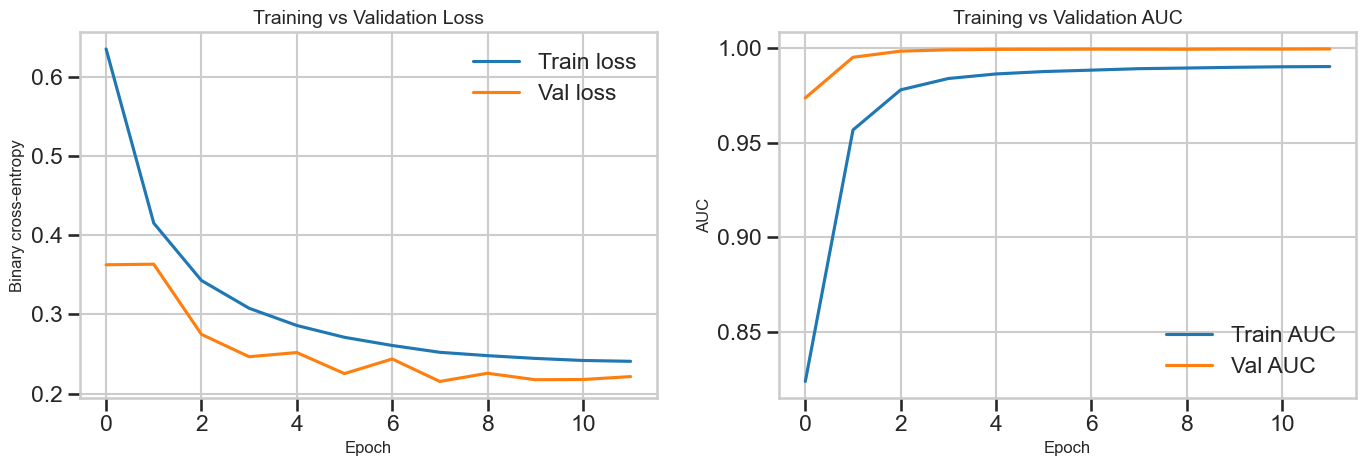

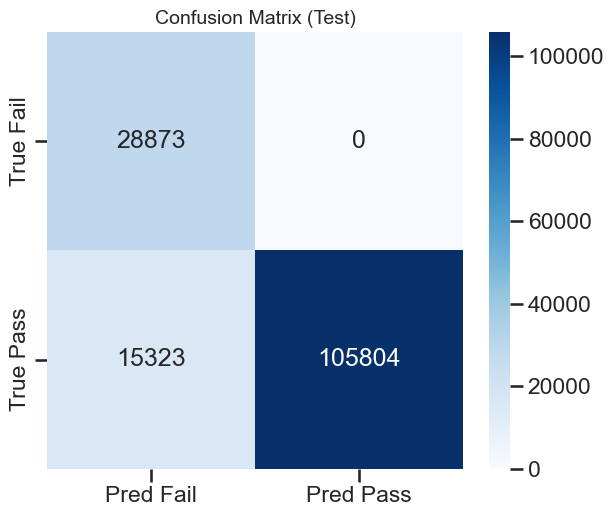

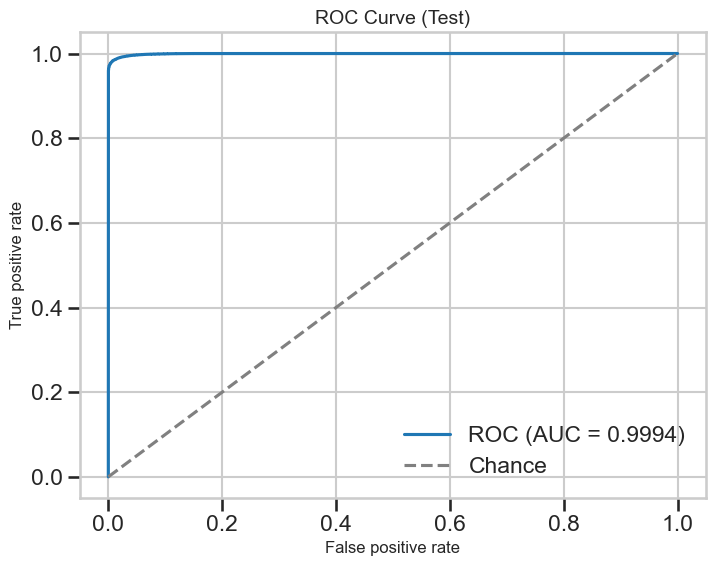

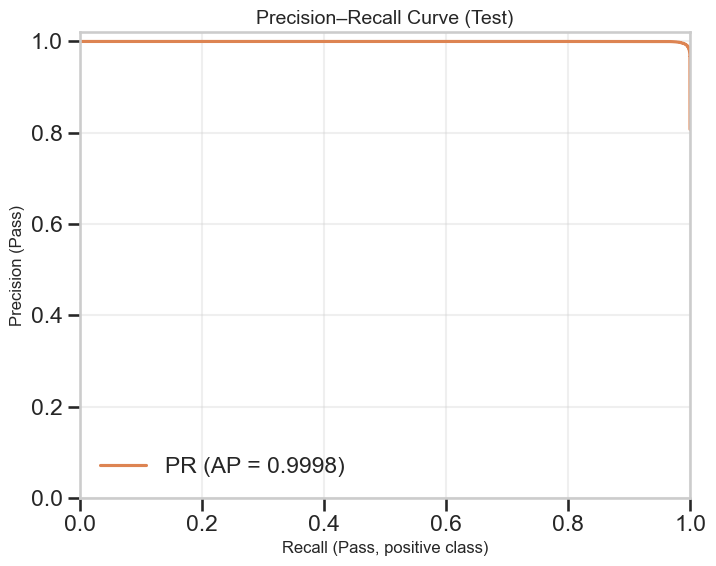

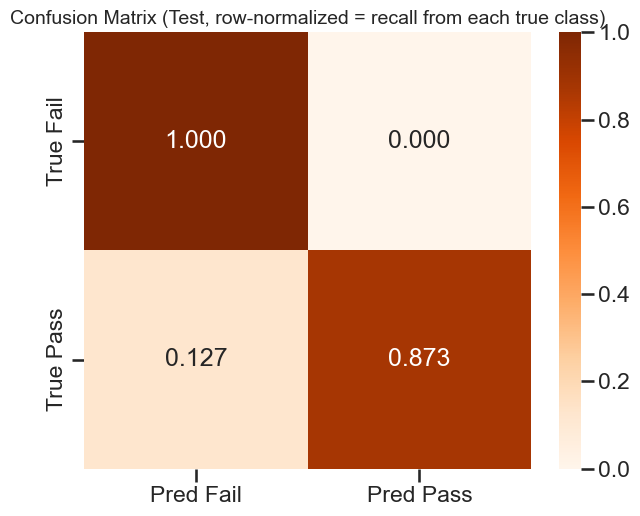

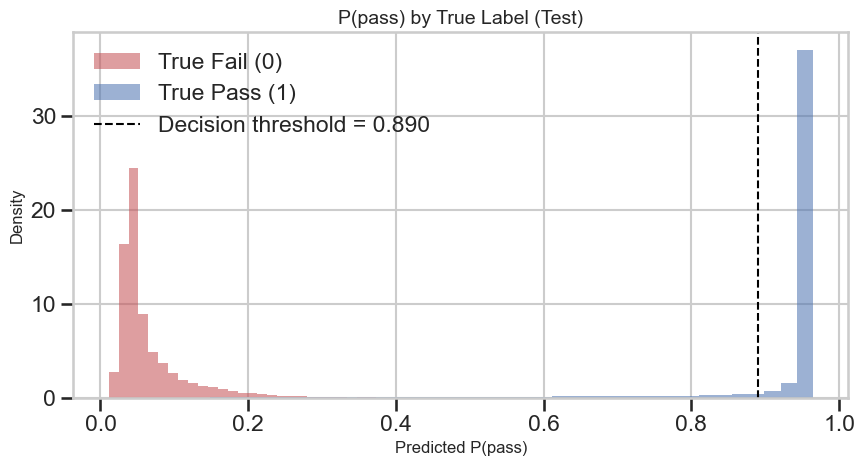

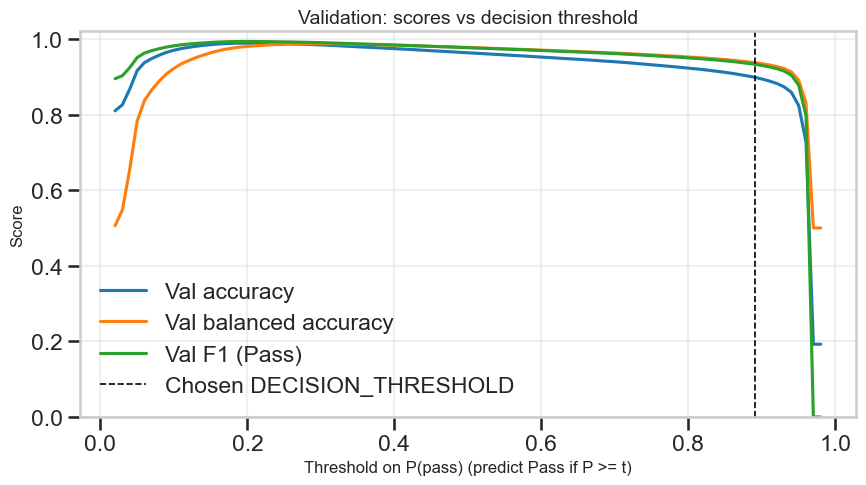

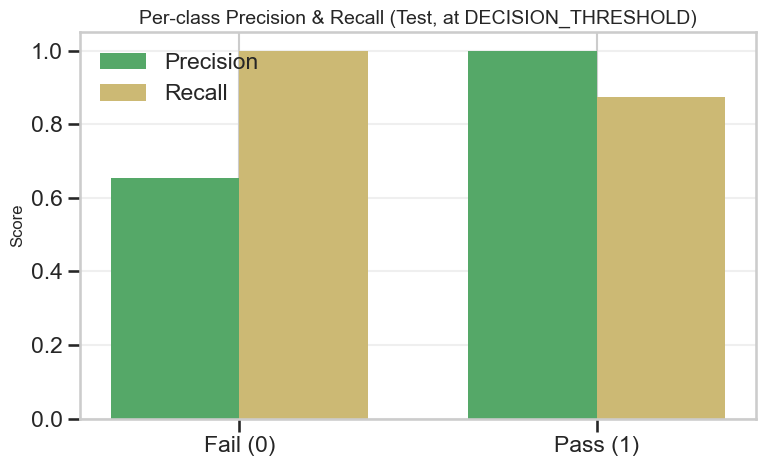

In [9]:
hist = history.history

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hist["loss"], label="Train loss")
ax[0].plot(hist["val_loss"], label="Val loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Binary cross-entropy")
ax[0].legend()

if "val_auc" in hist:
    ax[1].plot(hist["auc"], label="Train AUC")
    ax[1].plot(hist["val_auc"], label="Val AUC")
    ax[1].set_title("Training vs Validation AUC")
    ax[1].set_ylabel("AUC")
else:
    ax[1].plot(hist["accuracy"], label="Train accuracy")
    ax[1].plot(hist["val_accuracy"], label="Val accuracy")
    ax[1].set_title("Training vs Validation Accuracy")
    ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Pred Fail", "Pred Pass"],
    yticklabels=["True Fail", "True Pass"],
    ax=ax,
)
ax.set_title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure(figsize=(7.5, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve (Test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Precision–recall (often more informative than ROC when classes are imbalanced)
prec_c, rec_c, _pr_thr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(rec_c, prec_c, color="#dd8452", label=f"PR (AP = {ap:.4f})")
ax.set_xlabel("Recall (Pass, positive class)")
ax.set_ylabel("Precision (Pass)")
ax.set_title("Precision–Recall Curve (Test)")
ax.legend(loc="lower left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix normalized by true class (diagonal = recall per row)
cm_row = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1e-12)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm_row,
    annot=True,
    fmt=".3f",
    cmap="Oranges",
    vmin=0,
    vmax=1,
    xticklabels=["Pred Fail", "Pred Pass"],
    yticklabels=["True Fail", "True Pass"],
    ax=ax,
)
ax.set_title("Confusion Matrix (Test, row-normalized = recall from each true class)")
plt.tight_layout()
plt.show()

# Distribution of predicted P(pass) by true label
y_test_flat = np.asarray(y_test).astype(int).ravel()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    y_proba[y_test_flat == 0],
    bins=40,
    alpha=0.55,
    label="True Fail (0)",
    density=True,
    color="#c44e52",
)
ax.hist(
    y_proba[y_test_flat == 1],
    bins=40,
    alpha=0.55,
    label="True Pass (1)",
    density=True,
    color="#4c72b0",
)
ax.axvline(
    DECISION_THRESHOLD,
    color="black",
    ls="--",
    lw=1.5,
    label=f"Decision threshold = {DECISION_THRESHOLD:.3f}",
)
ax.set_xlabel("Predicted P(pass)")
ax.set_ylabel("Density")
ax.set_title("P(pass) by True Label (Test)")
ax.legend()
plt.tight_layout()
plt.show()

# Validation: how metrics move with probability threshold (uses val_proba from training cell)
t_sweep = np.linspace(0.02, 0.98, 97)
y_val_flat_v = np.asarray(y_val).astype(int).ravel()
acc_s, ba_s, f1p_s = [], [], []
for t in t_sweep:
    vp = (val_proba >= t).astype(int)
    acc_s.append(float((vp == y_val_flat_v).mean()))
    ba_s.append(balanced_accuracy_score(y_val_flat_v, vp))
    f1p_s.append(f1_score(y_val_flat_v, vp, pos_label=1, zero_division=0))
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(t_sweep, acc_s, label="Val accuracy")
ax.plot(t_sweep, ba_s, label="Val balanced accuracy")
ax.plot(t_sweep, f1p_s, label="Val F1 (Pass)")
ax.axvline(
    DECISION_THRESHOLD,
    color="black",
    ls="--",
    lw=1.2,
    label="Chosen DECISION_THRESHOLD",
)
ax.set_xlabel("Threshold on P(pass) (predict Pass if P >= t)")
ax.set_ylabel("Score")
ax.set_title("Validation: scores vs decision threshold")
ax.legend(loc="best")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-class precision & recall at the chosen threshold
prec_01 = precision_score(
    y_test, y_pred, average=None, labels=[0, 1], zero_division=0
)
rec_01 = recall_score(
    y_test, y_pred, average=None, labels=[0, 1], zero_division=0
)
x_c = np.arange(2)
w = 0.36
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_c - w / 2, prec_01, width=w, label="Precision", color="#55a868")
ax.bar(x_c + w / 2, rec_01, width=w, label="Recall", color="#ccb974")
ax.set_xticks(x_c)
ax.set_xticklabels(["Fail (0)", "Pass (1)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision & Recall (Test, at DECISION_THRESHOLD)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



### 10. Save Model

Writes **`model.h5`** and **`scaler.pkl`** next to this notebook. The pickle matches **`backend/inference.py` (v2)**: `feature_columns`, `features_for_model`, `impute_values`, empty `performance_index_weights`, and `pipeline_version` **2**.



In [10]:
MODEL_PATH = "model.h5"
SCALER_PATH = "scaler.pkl"

model.save(MODEL_PATH)

artifact = {
    "scaler": scaler,
    "feature_columns": FEATURE_COLUMNS,
    "features_for_model": FEATURES_FOR_MODEL,
    "target_column": TARGET_COLUMN,
    "performance_index_weights": {},
    "performance_index_mins": {},
    "performance_index_maxs": {},
    "impute_values": IMPUTE_VALUES,
    "pipeline_version": 2,
    "decision_threshold": float(DECISION_THRESHOLD),
    "threshold_metric": THRESHOLD_METRIC,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "label_encoders": label_encoders,
    "random_seed": RANDOM_SEED,
}

joblib.dump(artifact, SCALER_PATH)

print("Saved:", MODEL_PATH)
print("Saved:", SCALER_PATH)



Saved: model.h5
Saved: scaler.pkl


### 11. Prediction Function (New Student)

Loads the saved bundle and applies the **same recipe as training**: fill missing keys with **`impute_values`**, align columns to **`features_for_model`**, **`MinMaxScaler.transform`**, then the Keras model. Returns **Pass/Fail** and **`P(pass)`**.



In [11]:
def predict_student_pass_fail(student: dict, model_path=MODEL_PATH, artifact_path=SCALER_PATH, threshold=None):
    """Predict pass/fail for one student (v2 tabular artifact or legacy v1 with performance_index)."""
    art = joblib.load(artifact_path)
    mdl = keras.models.load_model(model_path)

    scaler_ = art["scaler"]
    feats = list(art["feature_columns"])
    feats_model = list(art["features_for_model"])
    impute = dict(art.get("impute_values") or {})
    wts = art.get("performance_index_weights") or {}

    row = {}
    for k in feats:
        v = student.get(k)
        if v is None or (isinstance(v, str) and str(v).strip() == ""):
            row[k] = float(impute.get(k, 0.0))
        else:
            row[k] = float(v)

    X0 = pd.DataFrame([row])

    if isinstance(wts, dict) and len(wts) > 0:
        mins_ = art["performance_index_mins"]
        maxs_ = art["performance_index_maxs"]
        X0["engagement"] = X0["attendance"] * X0["study_hours"]
        X0["stress_sleep"] = X0["mental_stress"] * X0["sleep_hours"]
        eps = 1e-8
        norm = {}
        for c in wts.keys():
            norm[c] = (X0[c] - float(mins_[c])) / (float(maxs_[c] - mins_[c]) + eps)
        X0["performance_index"] = float(sum(wts[c] * float(norm[c].iloc[0]) for c in wts.keys()))

    X0 = X0.reindex(columns=list(feats_model), fill_value=0.0)
    Xs = scaler_.transform(X0.to_numpy(dtype=np.float64, copy=False))

    p_pass = float(mdl.predict(Xs, verbose=0).reshape(-1)[0])
    thr = float(threshold) if threshold is not None else float(art.get("decision_threshold", 0.5))
    label = "Pass" if p_pass >= thr else "Fail"

    return {
        "prediction_label": label,
        "pass_probability": p_pass,
        "fail_probability": 1.0 - p_pass,
    }


# Example: first training row (all feature keys present)
example_student = {k: float(data.iloc[0][k]) for k in FEATURE_COLUMNS}
print(predict_student_pass_fail(example_student))



{'prediction_label': 'Pass', 'pass_probability': 0.9623082280158997, 'fail_probability': 0.03769177198410034}


### 13. Hidden-Layer Graph and Weight Update (Initial -> Trained)

This section visualizes your BPNN structure (input -> hidden layers -> output) and quantifies how weights changed after backpropagation.

> Note: if `initial_weights_snapshot` was not saved during the original training run, this cell reconstructs initial weights by rebuilding the same architecture with `RANDOM_SEED`.

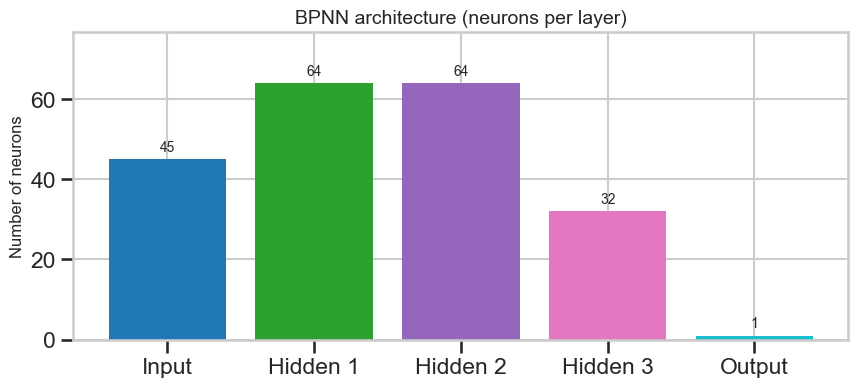

,layer,shape,mean_abs_initial,mean_abs_final,mean_abs_delta,max_abs_delta,l2_delta
0,Dense 1,"(45, 64)",0.117720,0.035850,0.092120,0.470249,5.917235
1,Dense 2,"(64, 64)",0.107566,0.023435,0.092499,0.296445,6.939808
2,Dense 3,"(64, 32)",0.124292,0.031053,0.101838,0.270182,5.365933
3,Dense 4,"(32, 1)",0.204762,0.110948,0.121227,0.305412,0.858360


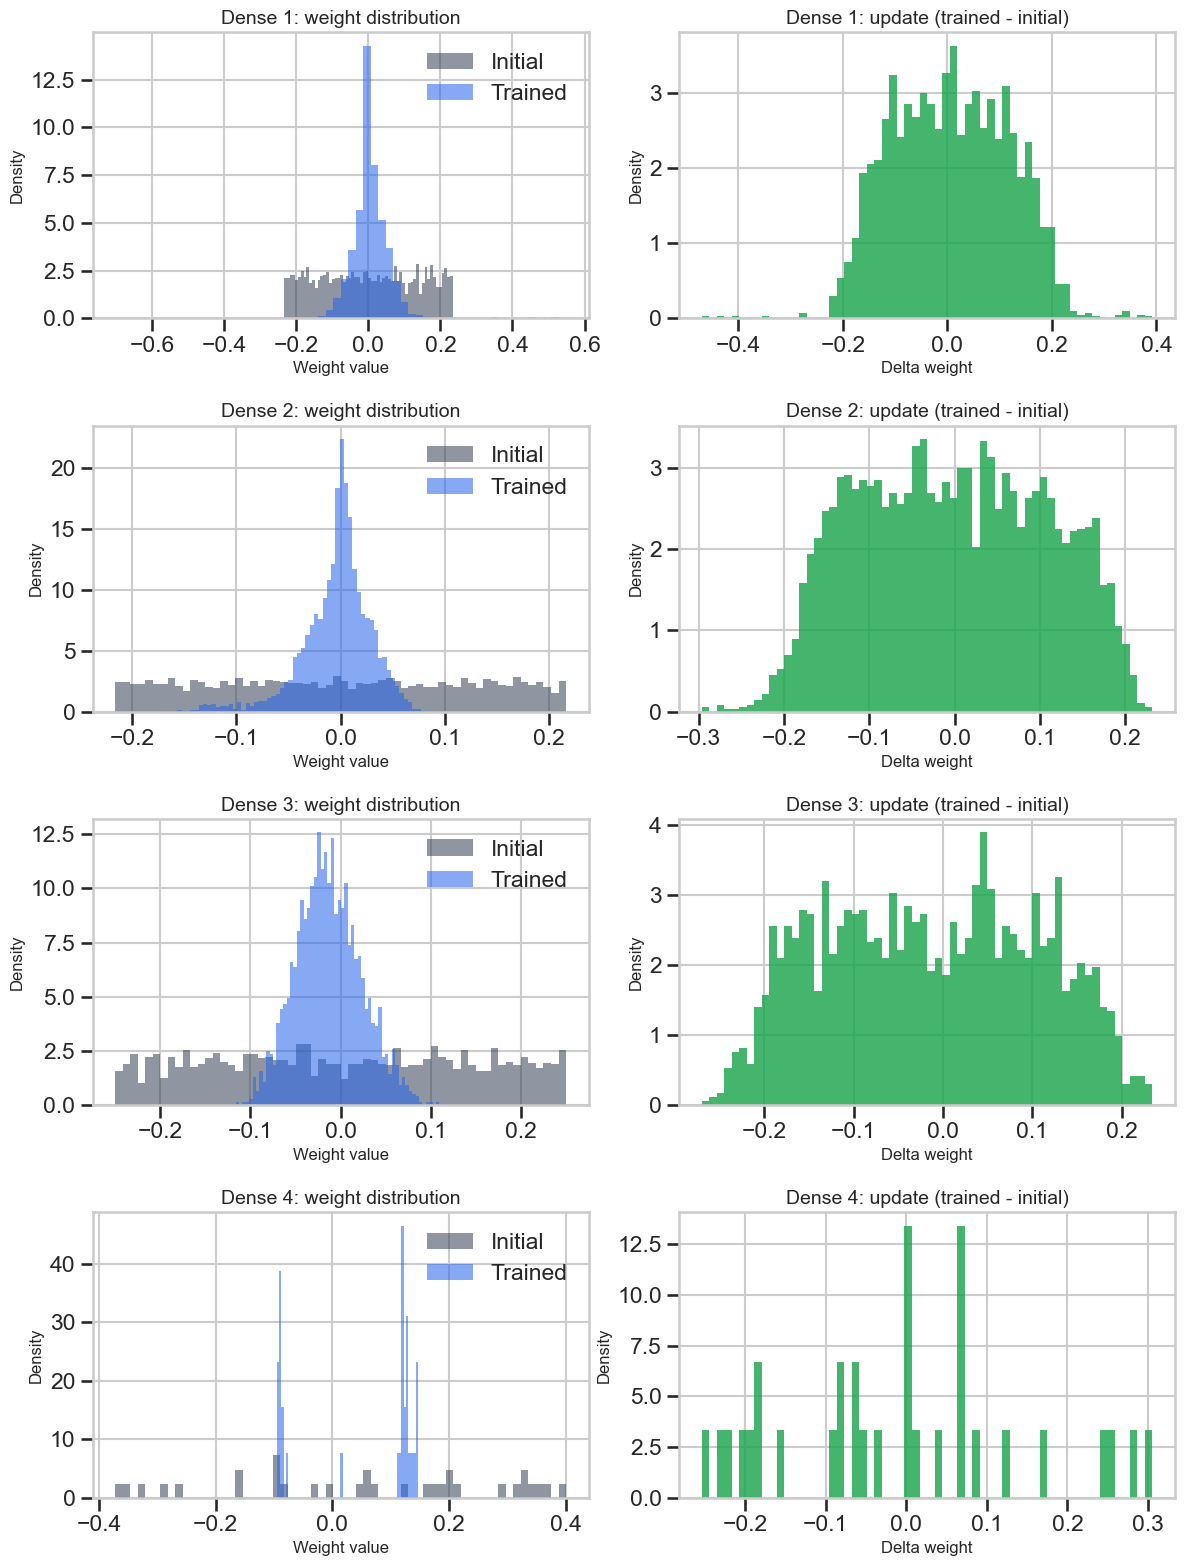

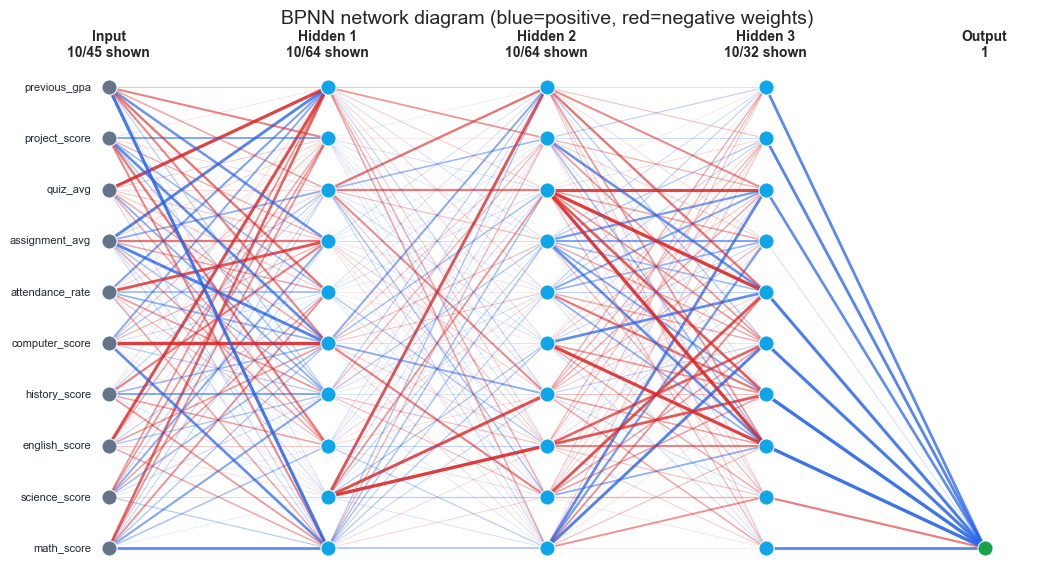

Interpretation:
- Hidden layers are the Dense layers before the final sigmoid output layer.
- Larger mean_abs_delta / l2_delta indicates stronger parameter updates by backpropagation.
- If distributions shifted noticeably, the model learned non-trivial feature interactions.
- In the network diagram, blue links are positive weights and red links are negative; thicker lines have larger magnitude.


In [12]:
# Hidden-layer architecture graph + weight update analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf

# --- 1) Architecture graph (neurons per layer) ---
input_dim = int(X_train_s.shape[1])
dense_layers_trained = [ly for ly in model.layers if isinstance(ly, layers.Dense)]

layer_labels = ["Input"] + [f"Hidden {i+1}" for i in range(max(0, len(dense_layers_trained) - 1))] + ["Output"]
layer_sizes = [input_dim] + [int(ly.units) for ly in dense_layers_trained]

plt.figure(figsize=(10, 4))
_bar_colors = plt.cm.tab10(np.linspace(0, 0.9, len(layer_sizes)))
plt.bar(layer_labels, layer_sizes, color=_bar_colors)
plt.title("BPNN architecture (neurons per layer)")
plt.ylabel("Number of neurons")
for i, v in enumerate(layer_sizes):
    plt.text(i, v + max(layer_sizes) * 0.02, str(v), ha="center", va="bottom", fontsize=10)
plt.ylim(0, max(layer_sizes) * 1.2)
plt.show()

# --- 2) Build an initial-weight reference model ---
# If you previously stored initial weights, use them; otherwise reconstruct with same seed.
if "initial_weights_snapshot" in globals() and isinstance(initial_weights_snapshot, list):
    init_weight_tensors = initial_weights_snapshot
else:
    tf.keras.utils.set_random_seed(RANDOM_SEED)
    init_model = models.clone_model(model)
    init_model.build(model.input_shape)
    init_weight_tensors = init_model.get_weights()

# Build a same-shape clone to map initial tensors to specific Dense layers safely.
tf.keras.utils.set_random_seed(RANDOM_SEED)
init_model_for_dense = models.clone_model(model)
init_model_for_dense.build(model.input_shape)
if "initial_weights_snapshot" in globals() and isinstance(initial_weights_snapshot, list):
    init_model_for_dense.set_weights(initial_weights_snapshot)

# Extract Dense kernels only (skip biases and non-Dense params like BatchNorm gamma/beta).
init_dense_kernels = []
final_dense_kernels = []
for l_init, l_trained in zip(init_model_for_dense.layers, model.layers):
    if isinstance(l_trained, layers.Dense):
        w0 = l_init.get_weights()
        w1 = l_trained.get_weights()
        if w0 and w1:
            init_dense_kernels.append(w0[0])
            final_dense_kernels.append(w1[0])

# --- 3) Summarize update magnitude per Dense layer ---
rows = []
for i, (w0, w1) in enumerate(zip(init_dense_kernels, final_dense_kernels), start=1):
    delta = w1 - w0
    rows.append(
        {
            "layer": f"Dense {i}",
            "shape": str(w1.shape),
            "mean_abs_initial": float(np.mean(np.abs(w0))),
            "mean_abs_final": float(np.mean(np.abs(w1))),
            "mean_abs_delta": float(np.mean(np.abs(delta))),
            "max_abs_delta": float(np.max(np.abs(delta))),
            "l2_delta": float(np.linalg.norm(delta)),
        }
    )

update_df = pd.DataFrame(rows)
display(update_df)

# --- 4) Visual: initial vs final distribution + delta distribution for each layer ---
n_layers = len(init_dense_kernels)
fig, axes = plt.subplots(n_layers, 2, figsize=(12, 4 * n_layers))
if n_layers == 1:
    axes = np.array([axes])

for i in range(n_layers):
    w0 = init_dense_kernels[i].ravel()
    w1 = final_dense_kernels[i].ravel()
    d = (final_dense_kernels[i] - init_dense_kernels[i]).ravel()

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    ax_left.hist(w0, bins=60, alpha=0.55, label="Initial", color="#334155", density=True)
    ax_left.hist(w1, bins=60, alpha=0.55, label="Trained", color="#2563eb", density=True)
    ax_left.set_title(f"Dense {i+1}: weight distribution")
    ax_left.set_xlabel("Weight value")
    ax_left.set_ylabel("Density")
    ax_left.legend()

    ax_right.hist(d, bins=60, color="#16a34a", alpha=0.8, density=True)
    ax_right.set_title(f"Dense {i+1}: update (trained - initial)")
    ax_right.set_xlabel("Delta weight")
    ax_right.set_ylabel("Density")

plt.tight_layout()
plt.show()

# --- 5) Network-style diagram (nodes + weighted connections) ---
# Keep the diagram readable by limiting drawn nodes per layer.
max_nodes_per_layer = 10
plot_sizes = [min(s, max_nodes_per_layer) for s in layer_sizes]

fig, ax = plt.subplots(figsize=(13, 7))
x_positions = np.arange(len(plot_sizes))
layer_nodes_xy = []

for li, n_nodes in enumerate(plot_sizes):
    ys = np.linspace(0, 1, n_nodes)
    xs = np.full_like(ys, x_positions[li], dtype=float)
    layer_nodes_xy.append((xs, ys))

# Draw connections using trained Dense kernels (input->hidden1, hidden1->hidden2, ..., last hidden->output)
for li, kernel in enumerate(final_dense_kernels):
    left_n = plot_sizes[li]
    right_n = plot_sizes[li + 1]
    k = kernel[:left_n, :right_n]
    max_abs = np.max(np.abs(k)) + 1e-8

    x0s, y0s = layer_nodes_xy[li]
    x1s, y1s = layer_nodes_xy[li + 1]
    for i in range(left_n):
        for j in range(right_n):
            w = float(k[i, j])
            color = "#2563eb" if w >= 0 else "#dc2626"
            alpha = 0.15 + 0.75 * (abs(w) / max_abs)
            lw = 0.4 + 2.0 * (abs(w) / max_abs)
            ax.plot([x0s[i], x1s[j]], [y0s[i], y1s[j]], color=color, alpha=alpha, linewidth=lw)

# Draw nodes on top
for li, (xs, ys) in enumerate(layer_nodes_xy):
    color = "#64748b" if li == 0 else ("#16a34a" if li == len(layer_nodes_xy) - 1 else "#0ea5e9")
    ax.scatter(xs, ys, s=120, c=color, edgecolor="white", linewidth=0.8, zorder=3)

# Label visible input nodes with feature names.
if "FEATURES_FOR_MODEL" in globals() and len(FEATURES_FOR_MODEL) >= plot_sizes[0]:
    input_feature_labels = list(FEATURES_FOR_MODEL[:plot_sizes[0]])
else:
    input_feature_labels = [f"x{i+1}" for i in range(plot_sizes[0])]

x_in, y_in = layer_nodes_xy[0]
for yi, name in zip(y_in, input_feature_labels):
    ax.text(x_in[0] - 0.08, yi, name, ha="right", va="center", fontsize=8, color="#1f2937")

for li, lbl in enumerate(layer_labels):
    shown = plot_sizes[li]
    full = layer_sizes[li]
    txt = f"{lbl}\n{shown}/{full} shown" if shown != full else f"{lbl}\n{full}"
    ax.text(x_positions[li], 1.06, txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("BPNN network diagram (blue=positive, red=negative weights)")
ax.set_xlim(-0.3, len(plot_sizes) - 0.7)
ax.set_ylim(-0.05, 1.12)
ax.axis("off")
plt.show()

print("Interpretation:")
print("- Hidden layers are the Dense layers before the final sigmoid output layer.")
print("- Larger mean_abs_delta / l2_delta indicates stronger parameter updates by backpropagation.")
print("- If distributions shifted noticeably, the model learned non-trivial feature interactions.")
print("- In the network diagram, blue links are positive weights and red links are negative; thicker lines have larger magnitude.")